In [19]:
# Imports
import sys
sys.path.insert(1, '/users/gj23442/analysis/pion-argon-xs-analysis/analysis/')
import importlib
import numpy as np
import awkward as ak
import pandas as pd
# from particle import Particle
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib as mpl
#from mpl_toolkits.mplot3d import Axes3D
from python.analysis import BeamParticleSelection, Master, SelectionTools, PFOSelection
from python.analysis import SelectionEvaluation as seval
from python.analysis import Tags, Plots
from python.pdhd_MC import beam_selection
from python.analysis.PFOSelection import Median
importlib.reload(Master)
importlib.reload(BeamParticleSelection)
importlib.reload(SelectionTools)
importlib.reload(Tags)
importlib.reload(beam_selection)

<module 'python.pdhd_MC.beam_selection' from '/users/gj23442/analysis/pion-argon-xs-analysis/analysis/python/pdhd_MC/beam_selection.py'>

In [31]:
filename = "/storage/2/gj23442/ana_pdhd_prod_beam_test_v4_gen_g4_IonScintPDExt_PDInt.root"
events = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [32]:
true_beam_mask = beam_selection.BeamTriggerSelection(events, return_property=True)
mask = true_beam_mask[0]
bi_evts = events.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamValidSelection(bi_evts)
bv_evts = bi_evts.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamTrackSelection(bv_evts)
track_evts = bv_evts.Filter([mask], [mask], returnCopy=True)

_, mask = beam_selection.BeamQualitySelection(track_evts)
beam_qual_evts = track_evts.Filter([mask], [mask], returnCopy=True)

median = Median(beam_qual_evts.recoParticles.beam_dEdX_noSCE)
mask = median < 3.0
pid_evts = beam_qual_evts.Filter([mask], [mask], returnCopy=True)

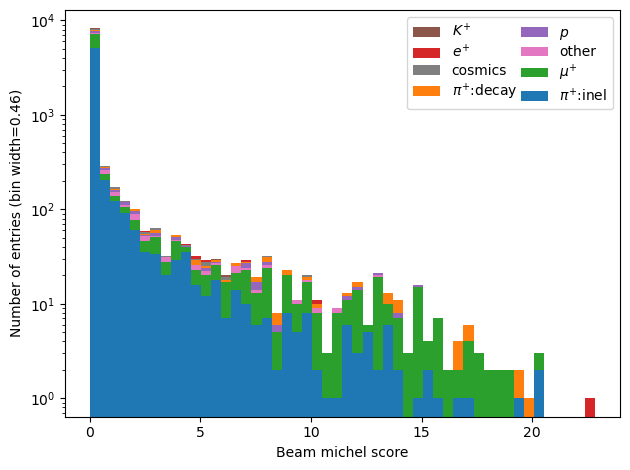

In [33]:
tags = Tags.GenerateBeamCandidateTags(pid_evts)
bins= np.linspace(0, 20, 50)
Plots.PlotTagged(pid_evts.recoParticles.beam_michelScore, tags, bins=50, y_scale='log', x_label="Beam michel score")

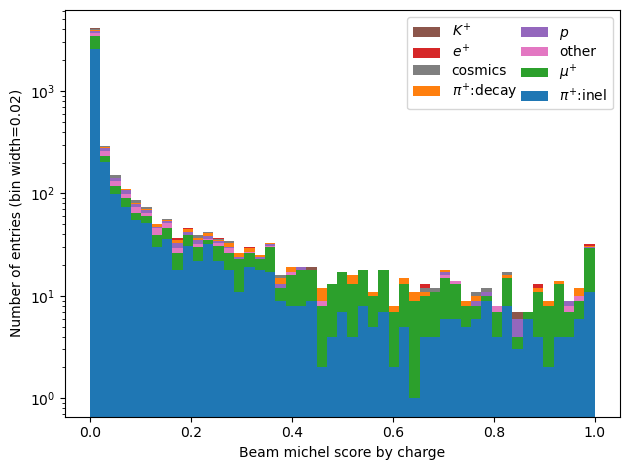

In [34]:
tags = Tags.GenerateBeamCandidateTags(pid_evts)
bins= np.linspace(0, 1, 50)
Plots.PlotTagged(pid_evts.recoParticles.beam_michelScore_by_charge, tags, bins=bins, y_scale='log', x_label="Beam michel score by charge")

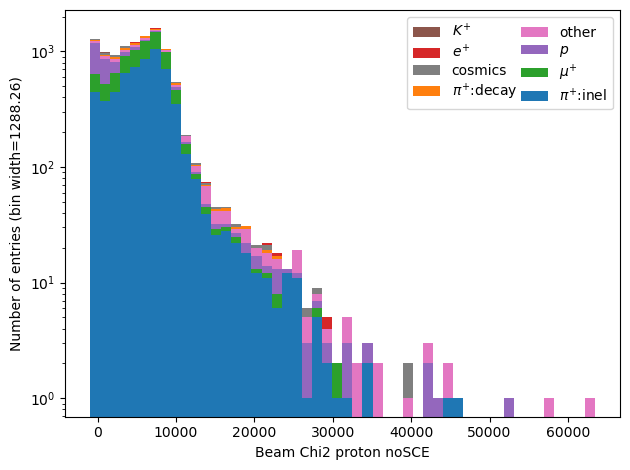

In [35]:
tags = Tags.GenerateBeamCandidateTags(beam_qual_evts)
bins= np.linspace(0, 1, 50)
Plots.PlotTagged(beam_qual_evts.recoParticles.beam_chi2_proton_noSCE, tags, bins=50, y_scale='log', x_label="Beam Chi2 proton noSCE")

In [5]:
ak.sum(pid_evts.recoParticles.beam_michelScore==0), ak.sum(pid_evts.recoParticles.beam_nHits==0)

(3940, 3940)

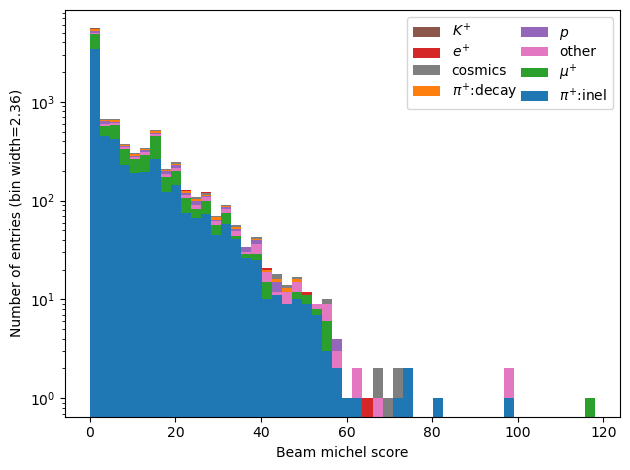

In [6]:
tags = Tags.GenerateBeamCandidateTags(pid_evts)
Plots.PlotTagged(pid_evts.recoParticles.beam_nHits, tags, bins=50, y_scale='log', x_label="Beam michel score")

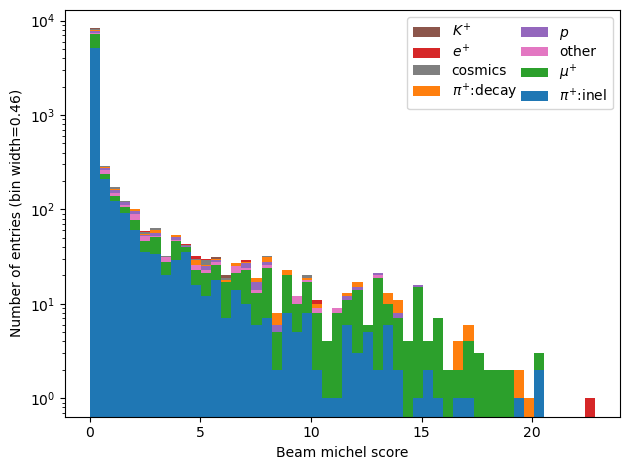

In [8]:
tags = Tags.GenerateBeamCandidateTags(pid_evts)
bins= np.linspace(0, 20, 50)
Plots.PlotTagged(pid_evts.recoParticles.beam_michelScore, tags, bins=50, y_scale='log', x_label="Beam michel score")

In [20]:
filename = "/storage/2/gj23442/ana_pdhd_prod_beam_test_v5__gen_g4_IonScintPDExt_PDInt.root"
events_old = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [21]:
true_beam_mask = beam_selection.BeamTriggerSelection(events_old, return_property=True)
mask = true_beam_mask[0]
bi_evts = events_old.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamValidSelection(bi_evts)
bv_evts = bi_evts.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamTrackSelection(bv_evts)
track_evts = bv_evts.Filter([mask], [mask], returnCopy=True)

_, mask = beam_selection.BeamQualitySelection(track_evts)
beam_qual_evts = track_evts.Filter([mask], [mask], returnCopy=True)

median = Median(beam_qual_evts.recoParticles.beam_dEdX_noSCE)
mask = median < 3.0
pid_evts = beam_qual_evts.Filter([mask], [mask], returnCopy=True)

In [22]:
ak.sum(pid_evts.recoParticles.beam_michelScore==-1)

8553

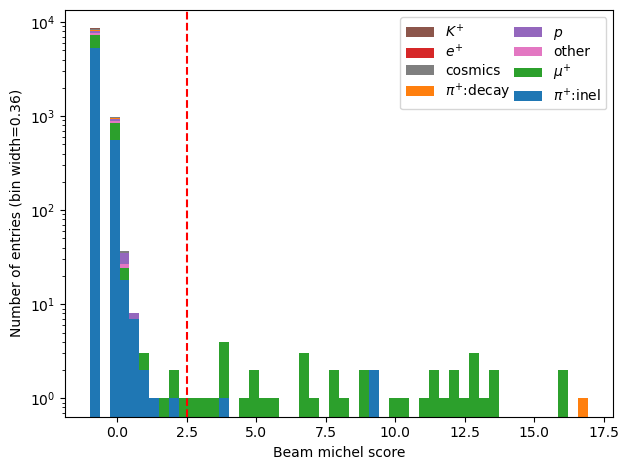

In [29]:
tags = Tags.GenerateBeamCandidateTags(pid_evts)
bins= np.linspace(0, 20, 50)
Plots.PlotTagged(pid_evts.recoParticles.beam_michelScore, tags, bins=50, y_scale='log', x_label="Beam michel score")
plt.axvline(x=2.5, color='r', linestyle='--', label='Michel Score= 2.5')

In [26]:
tags = Tags.GenerateBeamCandidateTags(pid_evts)
ak.sum(tags.mask.values[0]), ak.sum(tags.mask.values[2])

(5939, 2343)

In [15]:
ak.sum(tags.mask.values[2])

2343

In [27]:
mask = pid_evts.recoParticles.beam_michelScore < 2.5
michel_pid_evts = pid_evts.Filter([mask], [mask], returnCopy=True)

In [28]:
tags = Tags.GenerateBeamCandidateTags(michel_pid_evts)
ak.sum(tags.mask.values[0]), ak.sum(tags.mask.values[2])

(5936, 2306)

In [30]:
michel_pid_evts.event_index

<Array [11, 23, 38, ... 181376, 181384, 181389] type='9596 * int64'>

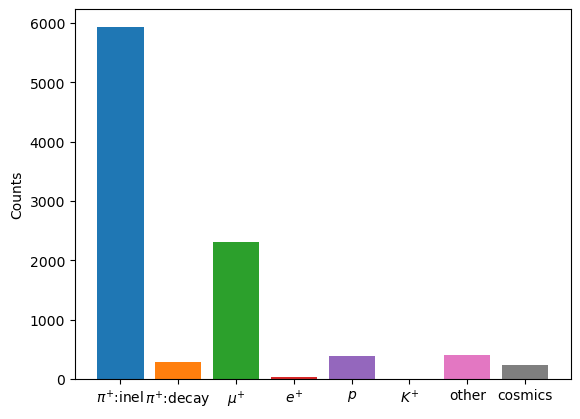

In [25]:
tags = Tags.GenerateBeamCandidateTags(michel_pid_evts)
counts = ak.sum(tags.mask.values, axis=-1)
#counts = counts/np.sum(counts)
plt.bar(tags.name.values, counts, color= tags.colour.values)
plt.ylabel("Counts")
plt.show()

In [10]:
purity = ak.sum(beam_selection.signal_mask(michel_pid_evts)) / len(beam_selection.signal_mask(michel_pid_evts))
print(f"Purity after PID selection: {purity:.2%}")

eff_bt = ak.sum(beam_selection.signal_mask(michel_pid_evts)) / ak.sum(beam_selection.signal_mask(events_old))
eff_true = ak.sum(beam_selection.true_signal_mask(michel_pid_evts)) / ak.sum(beam_selection.true_signal_mask(events_old))
print(f"Efficiency of the PID selection from backtracking: {eff_bt:.2%}")
print(f"Efficiency of the PID selection from truth info: {eff_true:.2%}")

Purity after PID selection: 64.92%
Efficiency of the PID selection from backtracking: 45.46%
Efficiency of the PID selection from truth info: 32.02%


In [4]:
filename = "/storage/2/gj23442/michelscore/pdhd_1gev_michelanalysis_testv1.root"
#filename = "/storage/2/gj23442/pdhd_prod_beam__gen_g4_IonScintPDExt_PDInt_266463_7_1_20251211T023321Z_detsim_reco1_pdhd_ntuple.root"
events_v1 = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [5]:
filename = "/storage/2/gj23442/michelscore/pdhd_1gev_michelanalysis_testv2.root"
#filename = "/storage/2/gj23442/pdhd_prod_beam__gen_g4_IonScintPDExt_PDInt_266463_7_1_20251211T023321Z_detsim_reco1_pdhd_ntuple.root"
events_v2 = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [6]:
filename = "/storage/2/gj23442/michelscore/pdhd_1gev_michelanalysis_testv3.root"
#filename = "/storage/2/gj23442/pdhd_prod_beam__gen_g4_IonScintPDExt_PDInt_266463_7_1_20251211T023321Z_detsim_reco1_pdhd_ntuple.root"
events_v3 = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [7]:
filename = "/storage/2/gj23442/michelscore/pdhd_1gev_michelanalysis_testv4.root"
#filename = "/storage/2/gj23442/pdhd_prod_beam__gen_g4_IonScintPDExt_PDInt_266463_7_1_20251211T023321Z_detsim_reco1_pdhd_ntuple.root"
events_v4 = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [20]:
filename = "/storage/2/gj23442/michelscore/pdhd_1gev_michelanalysis_testv5.root"
#filename = "/storage/2/gj23442/pdhd_prod_beam__gen_g4_IonScintPDExt_PDInt_266463_7_1_20251211T023321Z_detsim_reco1_pdhd_ntuple.root"
events_v5 = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [9]:
np.unique(events_v1.recoParticles.beam_michelScore, return_counts=True)

(array([-9.99000000e+02, -1.00000000e+00,  0.00000000e+00,  2.66167235e-05,
         1.26419644e-01]),
 array([89, 54,  4,  1,  1]))

In [10]:
np.unique(events_v2.recoParticles.beam_michelScore, return_counts=True)

(array([-9.99000000e+02,  0.00000000e+00,  2.66167235e-05,  1.26419644e-01,
         7.68414244e+00]),
 array([89, 57,  1,  1,  1]))

In [11]:
np.unique(events_v3.recoParticles.beam_michelScore, return_counts=True)

(array([-9.99000000e+02,  0.00000000e+00,  1.31317110e-08,  1.46090971e-06,
         6.91179937e-06,  1.38224686e-05,  2.57014161e-05,  2.92862241e-05,
         6.62808434e-05,  1.00170773e-04,  2.96873970e-04,  2.97427644e-04,
         7.43228412e-04,  1.83005844e-03,  1.92161649e-03,  2.20990603e-03,
         5.19348588e-03,  8.17021791e-03,  9.29840840e-03,  1.01111171e-02,
         1.73375787e-02,  8.41257731e-02,  1.98040955e-01,  2.43756801e-01,
         2.72562530e-01,  3.29161428e-01,  4.09298703e-01,  4.81040895e-01,
         6.17988589e-01,  6.18589371e-01,  7.94716228e-01,  1.90094846e+00,
         2.69284350e+00,  2.77285973e+00,  4.75578577e+00,  7.68414244e+00,
         7.83697123e+00,  8.03863902e+00,  1.03956749e+01]),
 array([89, 23,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1]))

In [12]:
np.unique(events_v4.recoParticles.beam_michelScore, return_counts=True)

(array([-9.99000000e+02, -1.00000000e+00,  0.00000000e+00,  1.31317110e-08,
         5.19348588e-03,  1.98040955e-01,  7.83697123e+00,  8.03863902e+00]),
 array([89, 54,  1,  1,  1,  1,  1,  1]))

In [21]:
np.unique(events_v5.recoParticles.beam_michelScore, return_counts=True)

(array([-9.99000000e+02, -1.00000000e+00,  0.00000000e+00,  1.31317110e-08,
         1.46090971e-06,  6.91179937e-06,  1.38224686e-05,  2.57014161e-05,
         2.92862241e-05,  1.00170773e-04,  2.97427644e-04,  7.43228412e-04,
         1.83005844e-03,  1.92161649e-03,  2.20990603e-03,  5.19348588e-03,
         8.17021791e-03,  9.29840840e-03,  1.01111171e-02,  8.41257731e-02,
         1.98040955e-01,  2.43756801e-01,  2.72562530e-01,  4.09298703e-01,
         4.81040895e-01,  7.94716228e-01,  2.69284350e+00,  4.75578577e+00,
         7.68414244e+00,  7.83697123e+00,  8.03863902e+00,  1.03956749e+01]),
 array([89, 21, 10,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1]))

In [10]:
## Hit collection from plane 1 fpr APA 1 but FV retained

filename = "/storage/2/gj23442/PDSPAnalyser_tests/ana_pdhd_prod_beam_test_v6__gen_g4_IonScintPDExt_PDInt.root"
events_v6 = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [11]:
true_beam_mask = beam_selection.BeamTriggerSelection(events_v6, return_property=True)
mask = true_beam_mask[0]
bi_evts = events_v6.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamValidSelection(bi_evts)
bv_evts = bi_evts.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamTrackSelection(bv_evts)
track_evts = bv_evts.Filter([mask], [mask], returnCopy=True)

_, mask = beam_selection.BeamQualitySelection(track_evts)
selected_v6_evts = track_evts.Filter([mask], [mask], returnCopy=True)

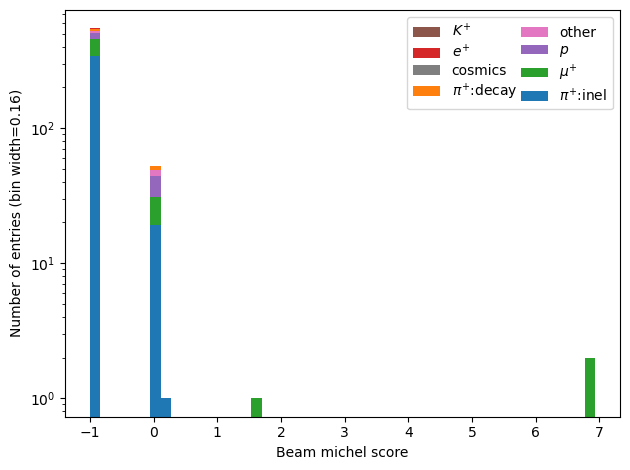

In [12]:
tags = Tags.GenerateBeamCandidateTags(selected_v6_evts)
bins= np.linspace(0, 20, 50)
Plots.PlotTagged(selected_v6_evts.recoParticles.beam_michelScore, tags, bins=50, y_scale='log', x_label="Beam michel score")

In [13]:
np.unique(selected_v6_evts.recoParticles.beam_michelScore, return_counts=True)

(array([-1.00000000e+00,  0.00000000e+00,  1.42333547e-05,  5.63984290e-05,
         6.61170579e-05,  1.90804087e-04,  4.71677868e-04,  1.35677333e-03,
         3.61335479e-02,  5.56112480e-02,  1.26419644e-01,  1.60194133e+00,
         6.83790917e+00,  6.92595607e+00]),
 array([545,  44,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1]))

In [14]:
## Hit collection from plane 1 fpr APA 1 and FV removed

filename = "/storage/2/gj23442/PDSPAnalyser_tests/ana_pdhd_prod_beam_test_v7__gen_g4_IonScintPDExt_PDInt.root"
events_v7 = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [15]:
## Beam Instrumentation Selection

true_beam_mask = beam_selection.BeamTriggerSelection(events_v7, return_property=True)
mask = true_beam_mask[0]
bi_evts = events_v7.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamValidSelection(bi_evts)
bv_evts = bi_evts.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamTrackSelection(bv_evts)
track_evts = bv_evts.Filter([mask], [mask], returnCopy=True)

_, mask = beam_selection.BeamQualitySelection(track_evts)
selected_v7_evts = track_evts.Filter([mask], [mask], returnCopy=True)

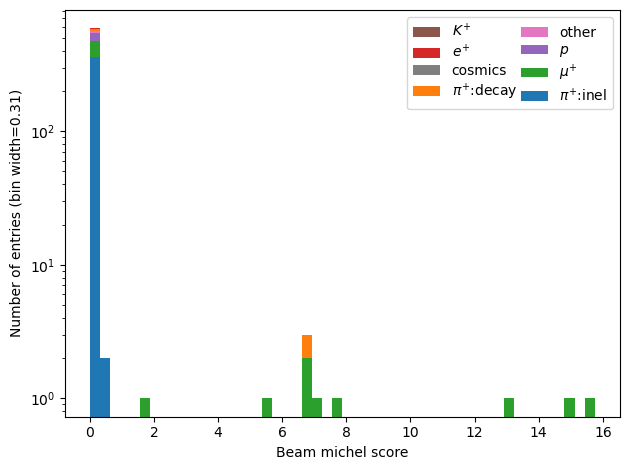

In [16]:
tags = Tags.GenerateBeamCandidateTags(selected_v7_evts)
bins= np.linspace(0, 20, 50)
Plots.PlotTagged(selected_v7_evts.recoParticles.beam_michelScore, tags, bins=50, y_scale='log', x_label="Beam michel score")

In [17]:
np.unique(selected_v7_evts.recoParticles.beam_michelScore, return_counts=True)

(array([0.00000000e+00, 5.29492965e-08, 2.31939303e-07, 9.55948316e-07,
        3.97609165e-06, 6.14117459e-06, 1.04715273e-05, 1.42333547e-05,
        2.80906797e-05, 3.13381992e-05, 4.44498401e-05, 4.93166626e-05,
        5.12546547e-05, 5.63984290e-05, 6.61170579e-05, 9.29947494e-05,
        1.13584688e-04, 1.90804087e-04, 2.60465466e-04, 3.07451388e-04,
        3.58141508e-04, 4.71677868e-04, 6.16254711e-04, 6.48737582e-04,
        7.95043370e-04, 9.23891000e-04, 9.37938385e-04, 1.12599414e-03,
        1.35677333e-03, 1.66668753e-03, 2.19979167e-03, 2.23655511e-03,
        2.79658598e-03, 3.71669227e-03, 4.29826709e-03, 4.58153293e-03,
        6.59319537e-03, 7.67899868e-03, 8.85644367e-03, 9.00225488e-03,
        1.17197545e-02, 1.36304734e-02, 1.43136105e-02, 1.71451968e-02,
        2.41603724e-02, 2.60929870e-02, 3.61335479e-02, 4.42606325e-02,
        5.56112480e-02, 7.65682051e-02, 7.66929296e-02, 1.24932556e-01,
        1.26419644e-01, 2.14108903e-01, 3.83065663e-01, 5.100852

In [18]:
## Hit collection from plane 1 fpr APA 1 and FV removed and interesting hit collection plane fixed

filename = "/storage/2/gj23442/PDSPAnalyser_tests/ana_pdhd_prod_beam_test_v8__gen_g4_IonScintPDExt_PDInt.root"
events_v8 = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [ ]:
true_beam_mask = beam_selection.BeamTriggerSelection(events_v8, return_property=True)
mask = true_beam_mask[0]
bi_evts = events_v8.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamValidSelection(bi_evts)
bv_evts = bi_evts.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamTrackSelection(bv_evts)
track_evts = bv_evts.Filter([mask], [mask], returnCopy=True)

_, mask = beam_selection.BeamQualitySelection(track_evts)
selected_v8_evts = track_evts.Filter([mask], [mask], returnCopy=True)

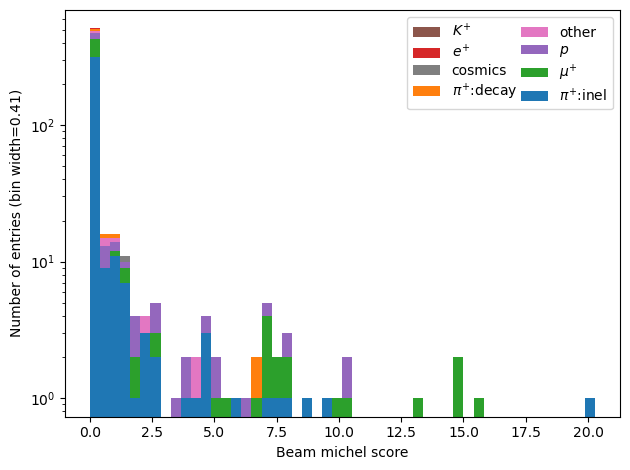

In [20]:
tags = Tags.GenerateBeamCandidateTags(selected_v8_evts)
bins= np.linspace(0, 20, 50)
Plots.PlotTagged(selected_v8_evts.recoParticles.beam_michelScore, tags, bins=50, y_scale='log', x_label="Beam michel score")

In [18]:
## Hit collection from plane 1 fpr APA 1 and hit collection plane fixed but FV included

filename = "/storage/2/gj23442/PDSPAnalyser_tests/ana_pdhd_prod_beam_test_v9__gen_g4_IonScintPDExt_PDInt.root"
events_v9 = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [19]:
## Beam Instrumentation Selection

true_beam_mask = beam_selection.BeamTriggerSelection(events_v9, return_property=True)
mask = true_beam_mask[0]
bi_evts = events_v9.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamValidSelection(bi_evts)
bv_evts = bi_evts.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamTrackSelection(bv_evts)
track_evts = bv_evts.Filter([mask], [mask], returnCopy=True)

_, mask = beam_selection.BeamQualitySelection(track_evts)
selected_v9_evts = track_evts.Filter([mask], [mask], returnCopy=True)

In [20]:
tags = Tags.GenerateBeamCandidateTags(selected_v9_evts)
muon_mask = tags.mask.values[2]

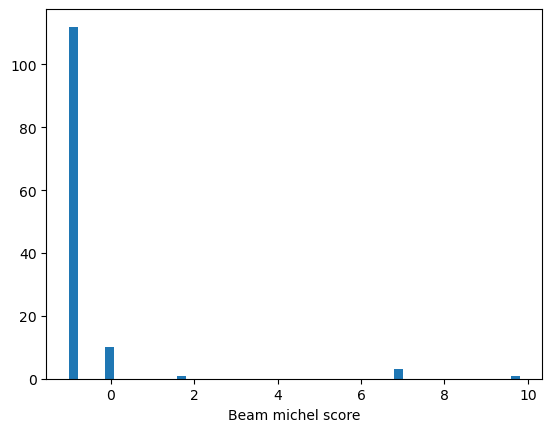

In [21]:
plt.hist(selected_v9_evts.recoParticles.beam_michelScore[muon_mask],bins=50)
plt.xlabel("Beam michel score")
plt.show()

In [25]:
ak.sum(selected_v9_evts.recoParticles.beam_michelScore == -1)

545

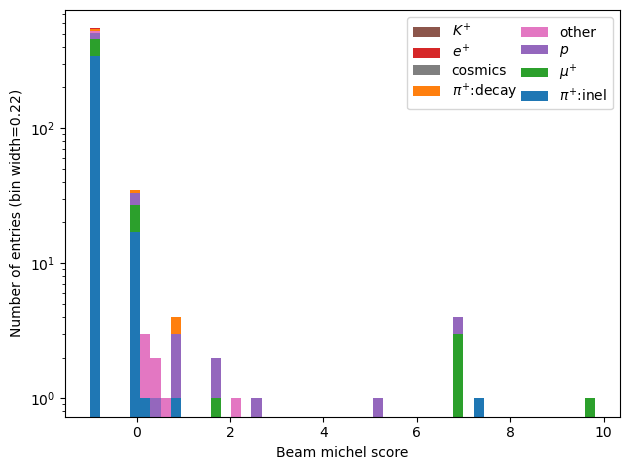

In [23]:
tags = Tags.GenerateBeamCandidateTags(selected_v9_evts)
bins= np.linspace(0, 20, 50)
Plots.PlotTagged(selected_v9_evts.recoParticles.beam_michelScore, tags, bins=50, y_scale='log', x_label="Beam michel score")

In [6]:
np.unique(selected_v9_evts.recoParticles.beam_michelScore, return_counts=True)

(array([-1.00000000e+00,  0.00000000e+00,  9.90020281e-08,  1.56196859e-06,
         3.54669783e-06,  3.74161732e-06,  2.52076989e-05,  5.29790427e-05,
         5.30009983e-05,  5.63984290e-05,  8.16056626e-05,  1.16244732e-04,
         1.30372820e-04,  1.87128812e-04,  2.86703882e-04,  3.25824960e-04,
         2.40946039e-03,  5.49424948e-03,  1.59201880e-02,  1.29141268e-01,
         1.98040955e-01,  2.32052306e-01,  3.71894381e-01,  5.00455817e-01,
         6.83092901e-01,  8.01290617e-01,  8.02161195e-01,  9.28353435e-01,
         9.39110457e-01,  1.60194133e+00,  1.75864768e+00,  2.09747198e+00,
         2.51890217e+00,  5.06788501e+00,  6.83790917e+00,  6.89933016e+00,
         6.92595607e+00,  6.98761582e+00,  7.29010913e+00,  9.80623512e+00]),
 array([545,  18,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1]))

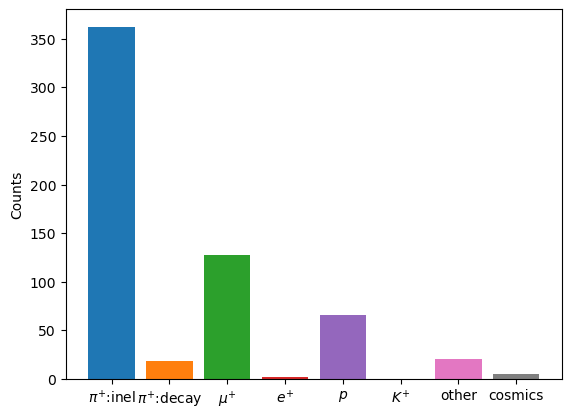

In [ ]:
tags = Tags.GenerateBeamCandidateTags(selected_v9_evts)
counts = ak.sum(tags.mask.values, axis=-1)
#counts = counts/np.sum(counts)
plt.bar(tags.name.values, counts, color= tags.colour.values)
plt.ylabel("Counts")
plt.show()

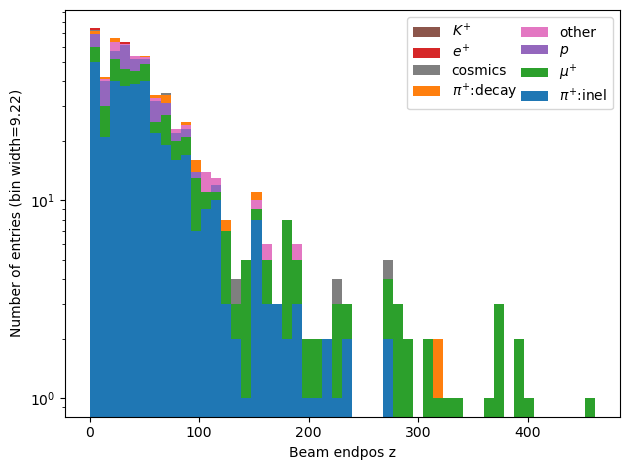

In [39]:
tags = Tags.GenerateBeamCandidateTags(selected_v9_evts)
Plots.PlotTagged(selected_v9_evts.recoParticles.beam_endPos.z, tags, bins=50, y_scale='log', x_label="Beam endpos z")

In [67]:
pdgs = selected_v9_evts.trueParticlesBT.beam_pdg
ak.sum(pdgs == -13)

129

In [78]:
selected_v9_evts.trueParticlesBT.pdg[tags.mask.values[2]][10]

<Array [-13] type='1 * int32'>

In [79]:
ak.firsts(selected_v9_evts.trueParticlesBT.pdg[tags.mask.values[2]])

<Array [-13, -13, -11, ... None, -13, None] type='127 * ?int32'>

In [64]:
np.unique(ak.flatten(selected_v9_evts.trueParticlesBT.pdg[tags.mask.values[2]]), return_counts=True)    

(array([-13, -11,  13,  22], dtype=int32), array([129,  19,  13,   1]))

In [63]:
np.unique(ak.fill_none(ak.firsts(selected_v9_evts.trueParticlesBT.pdg[tags.mask.values[2]]), -999), return_counts=True)

(array([-999,  -13,  -11,   13]), array([24, 90,  6,  7]))

In [2]:
import uproot

#filename = "/storage/1/st15719/dune/H4_v34b_1GeV_-27.7_10M_1.root"
filename = "/storage/2/gj23442/PDSPAnalyser_tests/ana_pdhd_prod_beam_test_v10__gen_g4_IonScintPDExt_PDInt.root"
tree = uproot.open(filename)

In [3]:
## Previous changes and vertex coordinates included

events_v10 = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [4]:
## Beam Instrumentation Selection

true_beam_mask = beam_selection.BeamTriggerSelection(events_v10, return_property=True)
mask = true_beam_mask[0]
bi_evts = events_v10.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamValidSelection(bi_evts)
bv_evts = bi_evts.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamTrackSelection(bv_evts)
track_evts = bv_evts.Filter([mask], [mask], returnCopy=True)

_, mask = beam_selection.BeamQualitySelection(track_evts)
selected_v10_evts = track_evts.Filter([mask], [mask], returnCopy=True)

In [6]:
min_length = 5
max_x = 0.
min_x = -200.
min_y = 200.
max_y = 500.
min_z = 25.

In [7]:
beam_len = selected_v10_evts.recoParticles.reco_beam_len
vertex_x = selected_v10_evts.recoParticles.reco_beam_michel_vertex_X
vertex_y = selected_v10_evts.recoParticles.reco_beam_michel_vertex_Y
vertex_z = selected_v10_evts.recoParticles.reco_beam_michel_vertex_Z
michel_end_x = selected_v10_evts.recoParticles.reco_beam_michel_end_X
michel_end_y = selected_v10_evts.recoParticles.reco_beam_michel_end_Y   
michel_end_z = selected_v10_evts.recoParticles.reco_beam_michel_end_Z

In [126]:
ak.sum(
    (np.maximum(vertex_x, michel_end_x) > max_x) |
    (np.minimum(vertex_x, michel_end_x) < min_x) |
    (np.maximum(vertex_y, michel_end_y) > max_y) |
    (np.minimum(vertex_y, michel_end_y) < min_y) |
    (np.minimum(vertex_z, michel_end_z) < min_z) |
    (beam_len < min_length)
)

545

In [30]:
tags = Tags.GenerateBeamCandidateTags(selected_v10_evts)
muon_mask = tags.mask.values[2]

In [31]:
ak.sum(tags.mask.values, axis=-1)

<Array [362, 18, 127, 2, 66, 0, 21, 5] type='8 * int64'>

In [14]:
np.unique(selected_v10_evts.recoParticles.beam_michelScore[muon_mask], return_counts=True)

(array([0.00000000e+00, 5.29492965e-08, 9.90020281e-08, 2.34506473e-07,
        5.69791609e-07, 8.36089157e-07, 2.49879704e-06, 2.56993717e-06,
        3.74161732e-06, 6.24003770e-06, 2.52076989e-05, 2.84347950e-05,
        3.13381992e-05, 3.56843424e-05, 5.59440309e-05, 5.63984290e-05,
        6.30776219e-05, 6.69808343e-05, 6.83012840e-05, 1.74030658e-04,
        3.25824960e-04, 6.16254711e-04, 8.67060864e-04, 8.79362027e-04,
        9.73330090e-04, 1.45250656e-03, 1.84245682e-03, 2.23655511e-03,
        2.40327733e-03, 2.86177779e-03, 3.09427736e-03, 4.56745317e-03,
        1.22922156e-02, 1.27212405e-02, 1.91428224e-02, 2.89948229e-02,
        4.90583341e-02, 6.73417372e-02, 9.00476184e-02, 9.19672325e-02,
        1.04200957e-01, 1.72193557e-01, 1.90892482e-01, 2.14108903e-01,
        3.23008363e-01, 1.07730204e+00, 1.60194133e+00, 1.60569817e+00,
        1.71565516e+00, 2.80653560e+00, 5.02679935e+00, 5.60347880e+00,
        6.83790917e+00, 6.92595607e+00, 6.97116044e+00, 6.987615

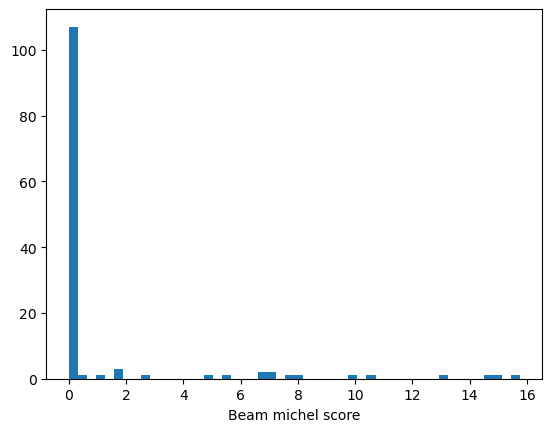

In [16]:
plt.hist(selected_v10_evts.recoParticles.beam_michelScore[muon_mask],bins=50)
plt.xlabel("Beam michel score")
plt.show()

In [108]:
selected_v10_evts.recoParticles.beam_endPos.z[tags.mask.values[2]][5]

322.9768981933594

In [118]:
selected_v10_evts.recoParticles.reco_beam_michel_end_Z[tags.mask.values[2]][5]

322.9768981933594

In [119]:
selected_v10_evts.recoParticles.reco_beam_michel_vertex_Z[tags.mask.values[2]][5]

0.4195714592933655

In [117]:
selected_v10_evts.trueParticlesBT.endPos.z[tags.mask.values[2]][5]

<Array [-1.87e+03, -1.87e+03, 327] type='3 * float64'>

In [116]:
selected_v10_evts.trueParticlesBT.pdg[tags.mask.values[2]][5]

<Array [-13, -13, -11] type='3 * int32'>

In [107]:
selected_v10_evts.recoParticles.track_end_pos.z[tags.mask.values[2]][5]

<Array [233, 330, 325] type='3 * float64'>

In [113]:
np.unique(ak.flatten(selected_v10_evts.trueParticlesBT.pdg[tags.mask.values[2]]))

<Array [-13, -11, 13, 22] type='4 * int32'>

In [111]:
selected_v10_evts.trueParticlesBT.pdg[tags.mask.values[2]][5]

<Array [-13, -13, -11] type='3 * int32'>

In [97]:
selected_v10_evts.recoParticles.track_end_pos.z[tags.mask.values[0]]

<Array [[], [86.9], ... [77.5, 77, -999]] type='362 * var * float64'>

In [53]:
beam_traj_pos = selected_v10_evts.trueParticles.beam_traj_pos
tags = Tags.GenerateTrueBeamParticleTags(selected_v10_evts)

In [54]:
tags.name.values

['$\\pi^{+}$:inel',
 '$\\pi^{+}$:decay',
 '$\\mu^{+}$',
 '$e^{+}$',
 '$p$',
 '$K^{+}$',
 'other']

In [56]:
ak.sum(tags.mask.values, axis=-1)

<Array [465, 49, 87, 0, 0, 0, 0] type='7 * int64'>

In [57]:
beam_traj_pos.z[tags.mask.values[2]]

<Array [[-275, -275, -274, ... 491, 491, 491]] type='87 * var * float64'>

In [71]:
selected_v10_evts.trueParticles.energy[tags.mask.values[2]][0]

<Array [625, 44.9, 34.2, 26] type='4 * float64'>

In [81]:
selected_v10_evts.trueParticles.pdg[tags.mask.values[2]][0], selected_v10_evts.trueParticles.pdg[tags.mask.values[2]][1], selected_v10_evts.trueParticles.pdg[tags.mask.values[2]][2]

(<Array [-13, -14, 12, -11] type='4 * int32'>,
 <Array [-13, -14, 12, -11] type='4 * int32'>,
 <Array [-13, -14, 12, -11] type='4 * int32'>)

In [80]:
selected_v10_evts.trueParticles.endPos.z[tags.mask.values[2]][0], selected_v10_evts.trueParticles.endPos.z[tags.mask.values[2]][1], selected_v10_evts.trueParticles.endPos.z[tags.mask.values[2]][2]

(<Array [86.2, -713, -3.01, 92.5] type='4 * float64'>,
 <Array [366, 334, -208, 364] type='4 * float64'>,
 <Array [387, 776, -1.49e+03, 389] type='4 * float64'>)

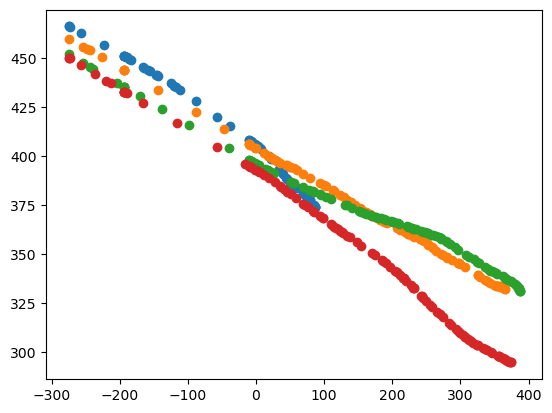

In [78]:
plt.scatter(beam_traj_pos.z[tags.mask.values[2]][0], beam_traj_pos.y[tags.mask.values[2]][0])
plt.scatter(beam_traj_pos.z[tags.mask.values[2]][1], beam_traj_pos.y[tags.mask.values[2]][1])
plt.scatter(beam_traj_pos.z[tags.mask.values[2]][2], beam_traj_pos.y[tags.mask.values[2]][2])
plt.scatter(beam_traj_pos.z[tags.mask.values[2]][3], beam_traj_pos.y[tags.mask.values[2]][3])


249

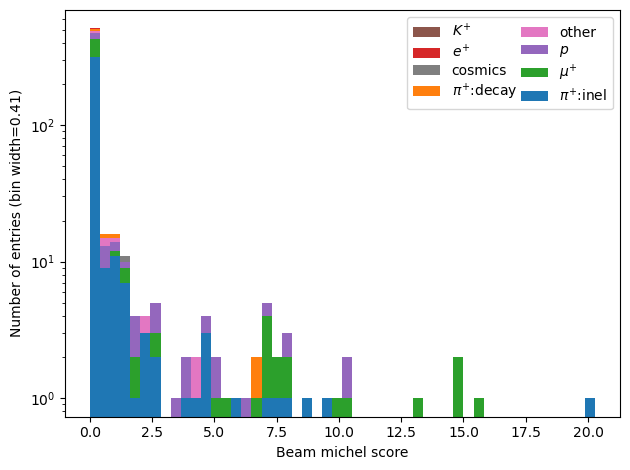

In [29]:
tags = Tags.GenerateBeamCandidateTags(selected_v10_evts)
Plots.PlotTagged(selected_v10_evts.recoParticles.beam_michelScore, tags, bins=50, y_scale='log', x_label="Beam michel score")
ak.sum(selected_v10_evts.recoParticles.beam_michelScore == 0)

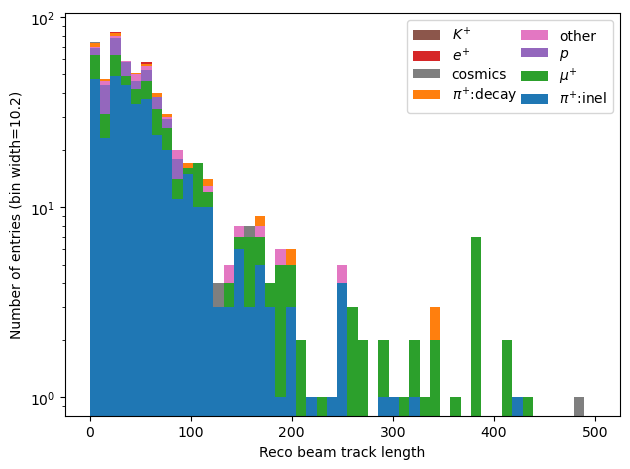

In [131]:
tags = Tags.GenerateBeamCandidateTags(selected_v10_evts)
bins= np.linspace(0, 500, 50)
Plots.PlotTagged(selected_v10_evts.recoParticles.reco_beam_len, tags, bins=bins, y_scale='log', x_label="Reco beam track length")

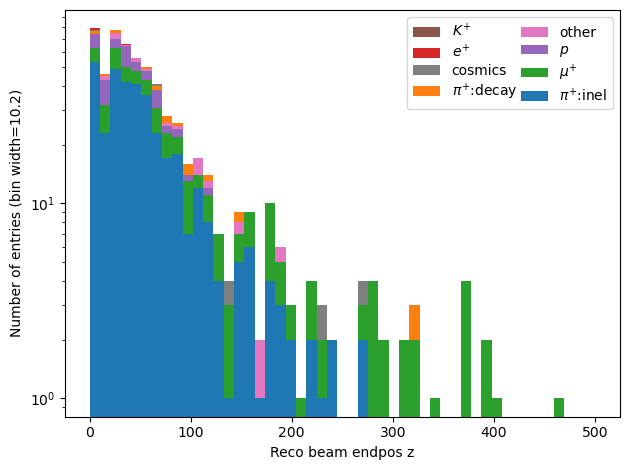

In [32]:
tags = Tags.GenerateBeamCandidateTags(selected_v10_evts)
bins= np.linspace(0, 500, 50)
Plots.PlotTagged(selected_v10_evts.recoParticles.beam_endPos.z, tags, bins=bins, y_scale='log', x_label="Reco beam endpos z")

In [30]:
tags = Tags.GenerateBeamCandidateTags(selected_v10_evts)
muon_mask = tags.mask.values[2]

In [31]:
ak.sum(muon_mask)

127

In [28]:
np.unique(selected_v10_evts.trueParticlesBT.beam_pdg, return_counts=True)

(array([      -211,        -13,        -11,         13,         22,
               211,       2212, 1000010020], dtype=int32),
 array([  5, 129,   2,   3,  15, 380,  66,   1]))

In [26]:
ak.sum(tags.mask.values, axis =-1)

<Array [362, 18, 127, 2, 66, 0, 21, 5] type='8 * int64'>

In [32]:
end_pos = selected_v10_evts.recoParticles.beam_endPos.z[muon_mask]
michel_endpos = selected_v10_evts.recoParticles.reco_beam_michel_end_Z[muon_mask]

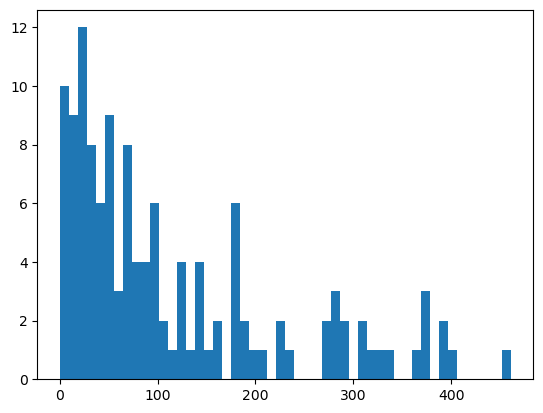

In [36]:
plt.hist(end_pos, bins=50)
plt.show()

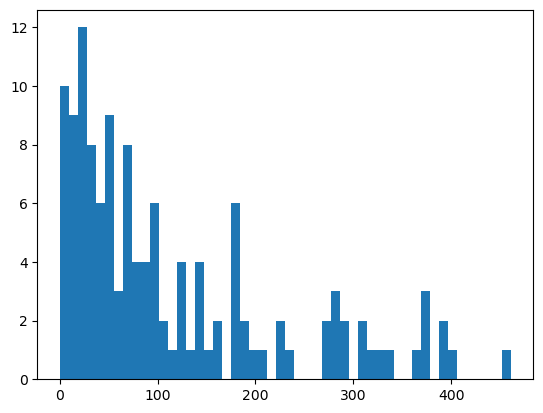

In [37]:
plt.hist(michel_endpos, bins=50)
plt.show()

In [33]:
np.unique(end_pos - michel_endpos, return_counts=True)

(array([0.        , 0.14678001, 0.16015744, 5.29675293]),
 array([124,   1,   1,   1]))

In [38]:
start_pos = selected_v10_evts.recoParticles.beam_startPos.z[muon_mask]
vertex_startpos = selected_v10_evts.recoParticles.reco_beam_michel_vertex_Z[muon_mask]

In [39]:
np.unique(start_pos - vertex_startpos, return_counts=True)

(array([-5.29675293, -0.16015744, -0.14678001,  0.        ]),
 array([  1,   1,   1, 124]))

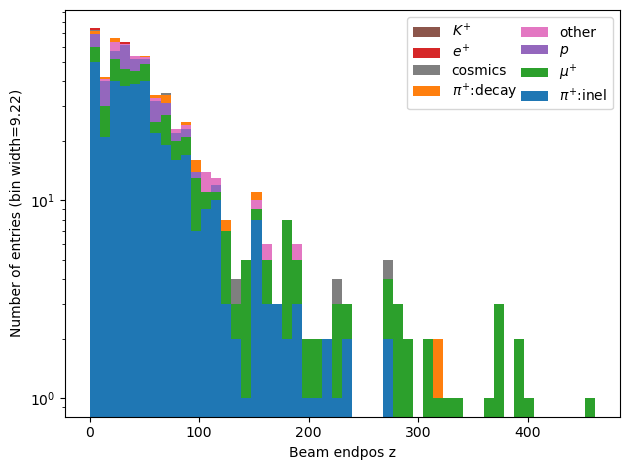

In [33]:
tags = Tags.GenerateBeamCandidateTags(selected_v10_evts)
Plots.PlotTagged(selected_v10_evts.recoParticles.beam_endPos.z, tags, bins=50, y_scale='log', x_label="Beam endpos z")

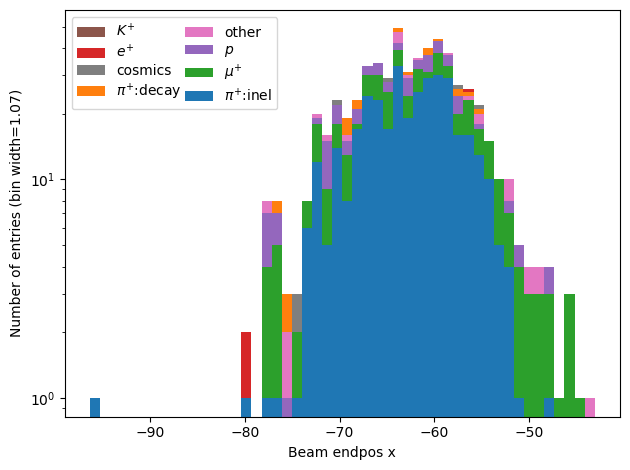

In [26]:
tags = Tags.GenerateBeamCandidateTags(selected_v10_evts)
Plots.PlotTagged(selected_v10_evts.recoParticles.reco_beam_michel_vertex_X, tags, bins=50, y_scale='log', x_label="Beam endpos x")

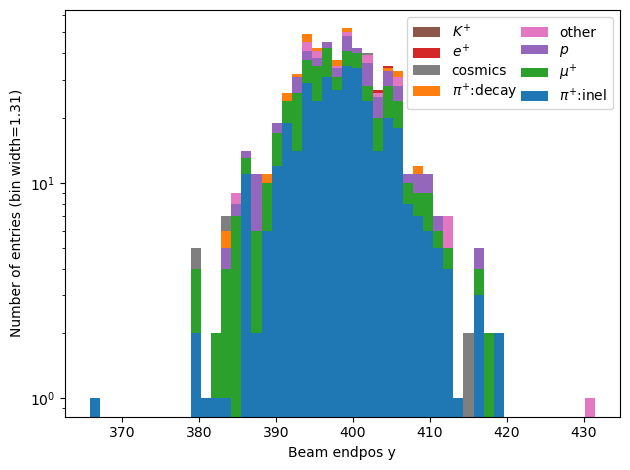

In [28]:
tags = Tags.GenerateBeamCandidateTags(selected_v10_evts)
Plots.PlotTagged(selected_v10_evts.recoParticles.reco_beam_michel_vertex_Y, tags, bins=50, y_scale='log', x_label="Beam endpos y")

In [37]:
tags = Tags.GenerateBeamCandidateTags(selected_v10_evts)
muon_mask = tags.mask.values[2]

In [38]:
vertex_z = selected_v10_evts.recoParticles.reco_beam_michel_vertex_Z[muon_mask]
start_z = selected_v10_evts.recoParticles.beam_startPos.z[muon_mask]

In [39]:
diff = vertex_z - start_z
np.unique(diff, return_counts=True)

(array([0.        , 0.14678001, 0.16015744, 5.29675293]),
 array([124,   1,   1,   1]))

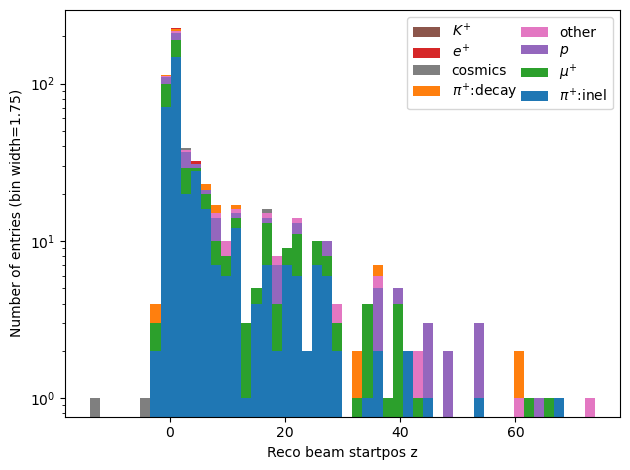

In [134]:
tags = Tags.GenerateBeamCandidateTags(selected_v10_evts)
Plots.PlotTagged(selected_v10_evts.recoParticles.beam_startPos.z, tags, bins=50, y_scale='log', x_label="Reco beam startpos z")

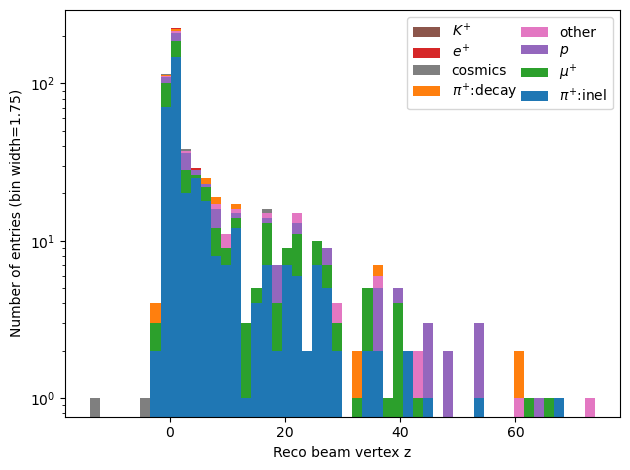

In [37]:
tags = Tags.GenerateBeamCandidateTags(selected_v10_evts)
Plots.PlotTagged(selected_v10_evts.recoParticles.reco_beam_michel_vertex_Z, tags, bins=50, y_scale='log', x_label="Reco beam vertex z")

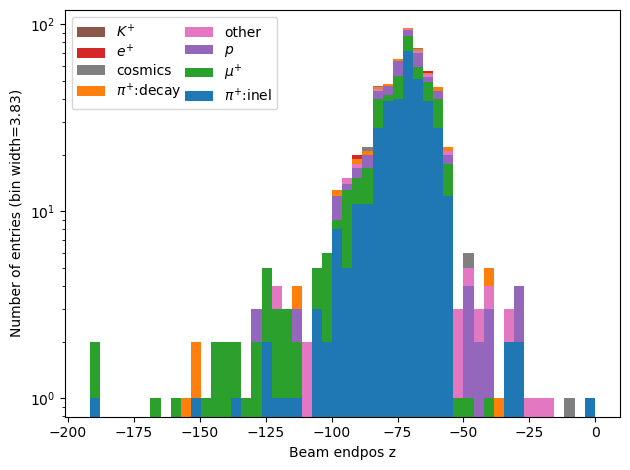

In [ ]:
tags = Tags.GenerateBeamCandidateTags(selected_v10_evts)
Plots.PlotTagged(selected_v10_evts.recoParticles.reco_beam_michel_end_X, tags, bins=50, y_scale='log', x_label="Beam endpos x")

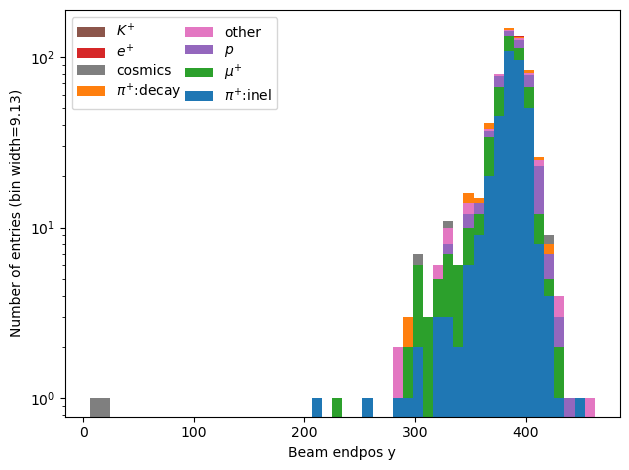

In [25]:
tags = Tags.GenerateBeamCandidateTags(selected_v10_evts)
Plots.PlotTagged(selected_v10_evts.recoParticles.reco_beam_michel_end_Y, tags, bins=50, y_scale='log', x_label="Beam endpos y")

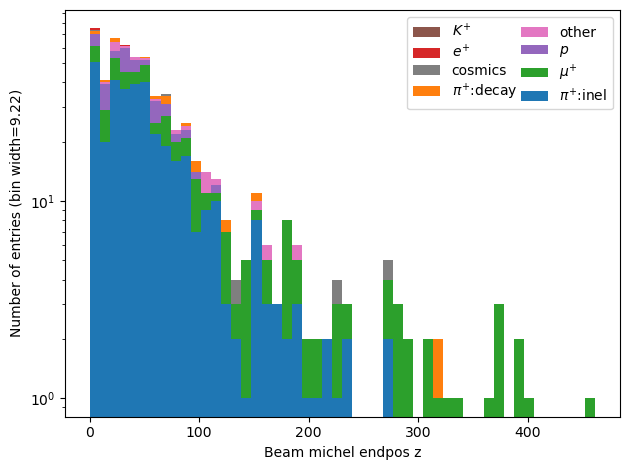

In [36]:
tags = Tags.GenerateBeamCandidateTags(selected_v10_evts)
Plots.PlotTagged(selected_v10_evts.recoParticles.reco_beam_michel_end_Z, tags, bins=50, y_scale='log', x_label="Beam michel endpos z")